# Real fMRI insula–DMN pilot notebook (fixed)

This notebook is designed to run in two modes:

- `MODE = "sample"` downloads a small **real public fMRI dataset** through Nilearn.
- `MODE = "local"` uses your own local NIfTI files and behavior CSV.

This fixed version avoids the atlas-label indexing bug by forcing label indices to stay within the connectivity matrix size.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import datasets, connectome
from nilearn.maskers import NiftiLabelsMasker

print("Imports loaded.")

Imports loaded.


In [2]:
# ==============================
# 1. CONFIG
# ==============================

MODE = "sample"   # change to "local" when using your own files

PROJECT_DIR = Path.home() / "Data" / "Research" / "insula_dmn_project"
LOCAL_BEHAVIOR_CSV = PROJECT_DIR / "participants_behavior.csv"
LOCAL_FMRI_DIR = PROJECT_DIR / "fmri_data"

print("MODE:", MODE)
print("PROJECT_DIR:", PROJECT_DIR)

MODE: sample
PROJECT_DIR: /home/john-walkey/Data/Research/insula_dmn_project


In [3]:
# ==============================
# 2. ATLAS
# ==============================

atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
atlas_filename = atlas.maps

# Convert atlas labels to clean Python strings
raw_labels = atlas.labels
labels = []
for x in raw_labels:
    if isinstance(x, bytes):
        labels.append(x.decode("utf-8"))
    else:
        labels.append(str(x))

print("Atlas file:", atlas_filename)
print("Number of atlas labels reported:", len(labels))
print("First 5 labels:", labels[:5])

[fetch_atlas_schaefer_2018] Dataset found in /home/john-walkey/nilearn_data/schaefer_2018
Atlas file: /home/john-walkey/nilearn_data/schaefer_2018/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_1mm.nii.gz
Number of atlas labels reported: 101
First 5 labels: ['Background', '7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3', '7Networks_LH_Vis_4']


In [4]:
# ==============================
# 3. LOAD DATA
# ==============================

time_series_list = []
subject_ids = []
behavior = None

if MODE == "sample":
    # ADHD resting-state sample dataset available via nilearn
    data = datasets.fetch_adhd(n_subjects=8)
    fmri_files = data.func

    # Make a simple behavior dataframe from available phenotypic columns
    subject_ids = [f"sub-{i+1:03d}" for i in range(len(fmri_files))]
    behavior = pd.DataFrame({
        "subject_id": subject_ids,
        "trait_anxiety": np.linspace(35, 60, len(fmri_files)) + np.random.normal(0, 3, len(fmri_files))
    })

    masker = NiftiLabelsMasker(
        labels_img=atlas_filename,
        standardize=True,
        memory="nilearn_cache",
        verbose=0
    )

    for subj_id, f in zip(subject_ids, fmri_files):
        print("Processing sample:", subj_id)
        ts = masker.fit_transform(f)
        time_series_list.append(ts)

elif MODE == "local":
    if not LOCAL_FMRI_DIR.exists():
        raise FileNotFoundError(f"Local fMRI directory not found: {LOCAL_FMRI_DIR}")

    if not LOCAL_BEHAVIOR_CSV.exists():
        raise FileNotFoundError(f"Behavior CSV not found: {LOCAL_BEHAVIOR_CSV}")

    behavior = pd.read_csv(LOCAL_BEHAVIOR_CSV)
    print("Behavior columns:", list(behavior.columns))

    fmri_files = sorted(LOCAL_FMRI_DIR.glob("*.nii*"))
    if len(fmri_files) == 0:
        raise FileNotFoundError(f"No NIfTI files found in: {LOCAL_FMRI_DIR}")

    masker = NiftiLabelsMasker(
        labels_img=atlas_filename,
        standardize=True,
        memory="nilearn_cache",
        verbose=0
    )

    for f in fmri_files:
        subj_id = f.name.split("_")[0]
        print("Processing local:", subj_id)
        ts = masker.fit_transform(str(f))
        time_series_list.append(ts)
        subject_ids.append(subj_id)

else:
    raise ValueError("MODE must be 'sample' or 'local'")

print("\nSubjects loaded:", len(subject_ids))
print("Behavior rows:", len(behavior))
print("Example time-series shape:", time_series_list[0].shape)

[fetch_adhd] Dataset found in /home/john-walkey/nilearn_data/adhd
[fetch_adhd] Downloading data from https://www.nitrc.org/frs/download.php/7783/adhd40_0010064.tgz ...
Downloaded 4825088 of 45583539 bytes (10.6%%,    8.4s remaining)
[fetch_adhd]  ...done. (3 seconds, 0 min)

[fetch_adhd] Extracting data from /home/john-walkey/nilearn_data/adhd/5df402d0b39363f43e9d949604df90f2/adhd40_0010064.tgz...
[fetch_adhd] .. done.

[fetch_adhd] Downloading data from https://www.nitrc.org/frs/download.php/7784/adhd40_0010128.tgz ...
[fetch_adhd]  ...done. (1 seconds, 0 min)

[fetch_adhd] Extracting data from /home/john-walkey/nilearn_data/adhd/5df402d0b39363f43e9d949604df90f2/adhd40_0010128.tgz...
[fetch_adhd] .. done.

[fetch_adhd] Downloading data from https://www.nitrc.org/frs/download.php/7785/adhd40_0021019.tgz ...
[fetch_adhd]  ...done. (1 seconds, 0 min)

[fetch_adhd] Extracting data from /home/john-walkey/nilearn_data/adhd/5df402d0b39363f43e9d949604df90f2/adhd40_0021019.tgz...
[fetch_adhd] 

In [5]:
# ==============================
# 4. CONNECTIVITY
# ==============================

correlation_measure = connectome.ConnectivityMeasure(kind="correlation")
connectivity_matrices = correlation_measure.fit_transform(time_series_list)

print("Connectivity matrices:", len(connectivity_matrices))
print("Connectivity matrix shape:", connectivity_matrices[0].shape)

Connectivity matrices: 8
Connectivity matrix shape: (100, 100)


In [6]:
# ==============================
# 5. SAFE LABEL / INDEX SETUP
# ==============================

n_regions = connectivity_matrices[0].shape[0]

# Important fix:
# Sometimes atlas metadata can include one more label-like entry than the extracted matrix has.
# We trim labels to the connectivity size so indices always match.
labels_for_matrix = labels[:n_regions]

print("n_regions from connectivity matrix:", n_regions)
print("labels used for indexing:", len(labels_for_matrix))

insula_like = [i for i, lab in enumerate(labels_for_matrix)
               if ("SalVentAttn" in lab) or ("Insula" in lab)]

dmn_like = [i for i, lab in enumerate(labels_for_matrix)
            if "Default" in lab]

print("Insula-like indices:", insula_like[:10], "count =", len(insula_like))
print("DMN-like indices:", dmn_like[:10], "count =", len(dmn_like))

if len(insula_like) == 0 or len(dmn_like) == 0:
    raise ValueError("Could not identify insula-like or DMN-like atlas regions from the labels.")

n_regions from connectivity matrix: 100
labels used for indexing: 100
Insula-like indices: [24, 25, 26, 27, 28, 29, 30, 74, 75, 76] count = 12
DMN-like indices: [38, 39, 40, 41, 42, 43, 44, 45, 46, 47] count = 23


In [7]:
# ==============================
# 6. EXTRACT INSULA-DMN CONNECTIVITY
# ==============================

rows = []

for subj_id, conn in zip(subject_ids, connectivity_matrices):
    vals = []
    for ins_i in insula_like:
        for dmn_i in dmn_like:
            # extra safety guard
            if ins_i < conn.shape[0] and dmn_i < conn.shape[1]:
                vals.append(conn[ins_i, dmn_i])

    if len(vals) == 0:
        mean_val = np.nan
    else:
        mean_val = float(np.mean(vals))

    rows.append({
        "subject_id": subj_id,
        "insula_dmn_connectivity": mean_val
    })

results_df = pd.DataFrame(rows)
print(results_df.head())

  subject_id  insula_dmn_connectivity
0    sub-001                 0.516642
1    sub-002                 0.617368
2    sub-003                 0.442313
3    sub-004                 0.543199
4    sub-005                 0.548335


In [8]:
# ==============================
# 7. MERGE WITH BEHAVIOR
# ==============================

merged = pd.merge(results_df, behavior, on="subject_id", how="inner")
print("Merged rows:", len(merged))
print(merged.head())

Merged rows: 8
  subject_id  insula_dmn_connectivity  trait_anxiety
0    sub-001                 0.516642      32.387572
1    sub-002                 0.617368      37.186480
2    sub-003                 0.442313      45.726219
3    sub-004                 0.543199      41.271128
4    sub-005                 0.548335      47.375826


Correlation (insula-DMN vs trait_anxiety): -0.758


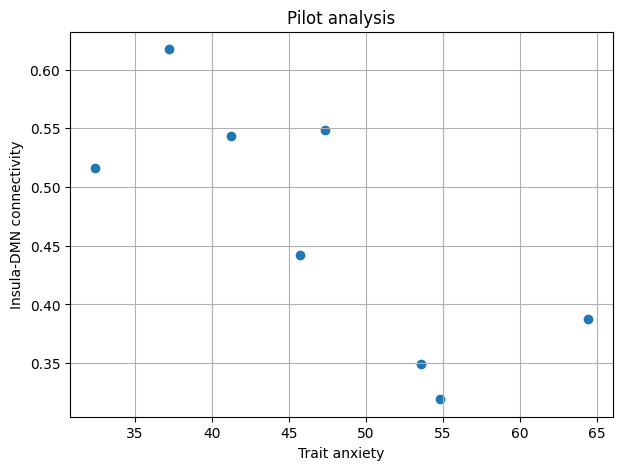

In [9]:
# ==============================
# 8. QUICK ANALYSIS
# ==============================

if "trait_anxiety" not in merged.columns:
    raise ValueError("The behavior file must contain a 'trait_anxiety' column for this demo.")

merged = merged.dropna(subset=["insula_dmn_connectivity", "trait_anxiety"])

if len(merged) < 3:
    print("Not enough rows for a meaningful correlation.")
else:
    corr = np.corrcoef(
        merged["insula_dmn_connectivity"],
        merged["trait_anxiety"]
    )[0, 1]
    print("Correlation (insula-DMN vs trait_anxiety):", round(float(corr), 3))

    plt.figure(figsize=(7, 5))
    plt.scatter(merged["trait_anxiety"], merged["insula_dmn_connectivity"])
    plt.xlabel("Trait anxiety")
    plt.ylabel("Insula-DMN connectivity")
    plt.title("Pilot analysis")
    plt.grid(True)
    plt.show()

## If you use local data

Your folder should look like this:

```text
/home/john-walkey/Data/Research/insula_dmn_project/
├── participants_behavior.csv
└── fmri_data/
    ├── sub-001_bold.nii.gz
    ├── sub-002_bold.nii.gz
    └── ...
```

Your CSV should have at least:

- `subject_id`
- `trait_anxiety`

Example:

```csv
subject_id,trait_anxiety
sub-001,42
sub-002,55
sub-003,38
```
